In [63]:
import numpy as np
import matplotlib.pyplot as plt
from numba import njit


@njit
def lax_wendroff(a,b,dx,dy,dt,N):
    A = np.zeros((N**2,N**2))
    
    for i in range(N):
        for j in range(N):
            k = i*N + j
            
            # calculate +/- indices from the current i,j
            ip = ((i+1)%N *N) + j
            im = ((i-1)%N *N) + j
            jp = i*N + (j+1)%N
            jm = i*N + (j-1)%N
            
            ipjp = ((i+1)%N *N) + (j+1)%N
            imjp = ((i-1)%N *N) + (j+1)%N
            ipjm = ((i+1)%N *N) + (j-1)%N
            imjm = ((i-1)%N *N) + (j-1)%N
            
            # Main Diagonal
            A[k,k] = -(a**2 * dt**2)/dx**2 - (b**2 * dt**2)/dy**2 + 1
    
            # Matrix Interior
            A[k, ip] = -b*dt/(2*dx) + (b**2 * dt**2)/(2*dx**2)
            A[k, im] = b*dt/(2*dx) + (b**2 * dt**2)/(2*dx**2)
            A[k, jp] = -a*dt/(2*dy) + (a**2 * dt**2)/(2*dy**2)
            A[k, jm] = a*dt/(2*dy) + (a**2 * dt**2)/(2*dy**2)
    
            A[k, ipjp] = (a*b*dt**2)/(4*dx*dy)
            A[k, imjp] = -(a*b*dt**2)/(4*dx*dy)
            A[k, ipjm] = -(a*b*dt**2)/(4*dx*dy)
            A[k, imjm] = (a*b*dt**2)/(4*dx*dy)
    
    return A

@njit
def ctu(a,b,dx,dy,dt,N):
    A = np.zeros((N**2,N**2))
    
    m = a*dt/dx
    v = b*dt/dy
    
    for i in range(N):
        for j in range(N):
            k = i*N + j
            
            # calculate +/- indices from the current i,j
            im = ((i-1)%N *N) + j
            jm = i*N + (j-1)%N
            
            imjm = ((i-1)%N *N) + (j-1)%N
            
            # Main Diagonal
            A[k,k] = (1-m)*(1-v)
            
            # Matrix Interior
            A[k, jm] = (1-v)*m
            A[k, im] = v*(1-m)
            
            A[k, imjm] = v*m
    
    return A

@njit
def flatten_array_2D(m):
    sz = m.size
    shp = m.shape
    
    m_flat = np.zeros((sz))
    
    for i in range(shp[0]):
        for j in range(shp[1]):
            k = i*N + j
            m_flat[k] = m[i,j]
            
    return m_flat

@njit
def flatten_array_3D(m,Nt):
    sz = int(m.size / Nt)
    shp = m.shape
    
    m_2D = np.zeros((Nt, sz))
    
    for i in range(shp[0]):
        for j in range(shp[1]):
            k = i*N + j
            m_2D[:,k] = m[i,j,:]
            
    return m_2D

def unflatten(m_flat):
    sz = m_flat.size
    N = int(np.sqrt(sz))
    m = np.reshape(m_flat, (N,N), order='C')
    return m

def exact_sol(x,y,t,a,b):
    x_tile, y_tile, t_tile = np.meshgrid(x,y,t)
    
    xp_tile = (x_tile - a*t_tile) % 1
    yp_tile = (y_tile - b*t_tile) % 1
    
    return np.exp( -( (xp_tile-0.5)**2 + (yp_tile-0.5)**2 ) / (3/20)**2 )

def L2norm(u_approx, u_exact):
    return np.sum( np.sqrt((u_exact - u_approx)**2) )


Ns = [128, 256, 512]
N = 32

a = 1
b = 2

x = np.linspace(0,1,N); dx = x[1] - x[0]
y = np.linspace(0,1,N); dy = y[1] - y[0]

dt = dx/(a+b) * 0.25
t = np.arange(0,10+dt, dt)

x_tile, y_tile = np.meshgrid(x,y)

u_exact_array = exact_sol(x,y,t,a,b)
u_exact = flatten_array_3D(u_exact_array, len(t))

idx_t1 = [min(range(len(t)), key=lambda i: abs(t[i]-1))][0]
idx_t10 = [min(range(len(t)), key=lambda i: abs(t[i]-10))][0]

print(idx_t1)

372


In [64]:
LW = lax_wendroff(a,b,dx,dy,dt,N)
L2_LW = np.zeros(t.shape)

u_init = np.exp( -( (x_tile-0.5)**2 + (y_tile-0.5)**2 ) / (3/20)**2 )
u = flatten_array_2D(u_init)

for idx in range(len(t)):
    
    u_exact_idx = u_exact[idx,:]
    L2_LW[idx] = L2norm(u,u_exact_idx)
    
    if idx == idx_t1:
        u_t1 = unflatten(u)
    elif idx == idx_t10:
        u_t10 = unflatten(u)
        
    u = LW @ u
    
print('Done.')

Done.


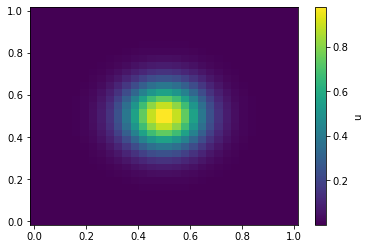

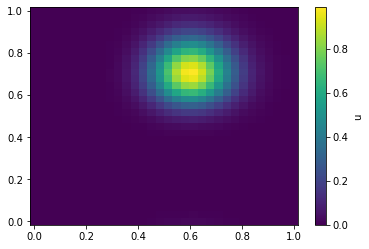

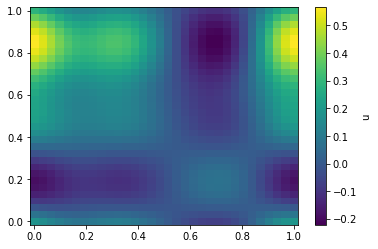

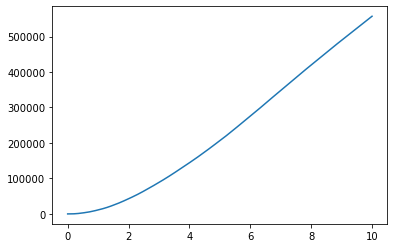

In [65]:
plt.figure()
plt.pcolormesh(x,y,u_init,shading='auto')
plt.colorbar(label='u')

plt.figure()
plt.pcolormesh(x,y,u_t1,shading='auto')
plt.colorbar(label='u')

plt.figure()
plt.pcolormesh(x,y,u_t10,shading='auto')
plt.colorbar(label='u')

plt.figure()
L2_LW_cumul = np.cumsum(L2_LW)
plt.plot(t, L2_LW_cumul)

plt.show()

In [59]:
CTU = ctu(a,b,dx,dy,dt,N)
L2_CTU = np.zeros(t.shape)

u_init = np.exp( -( (x_tile-0.5)**2 + (y_tile-0.5)**2 ) / (3/20)**2 )
u = flatten_array_2D(u_init)

for idx in range(len(t)):
    
    u_exact_idx = u_exact[idx,:]
    L2_CTU[idx] = L2norm(u,u_exact_idx)
    
    if idx == idx_t1:
        u_t1 = unflatten(u)
    elif idx == idx_t10:
        u_t10 = unflatten(u)
        
    u = CTU @ u
    
print('Done.')

Done.


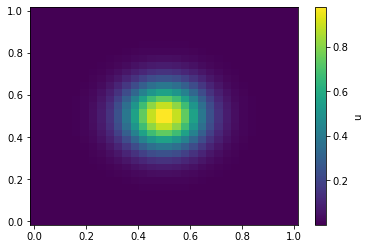

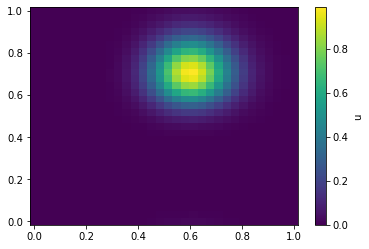

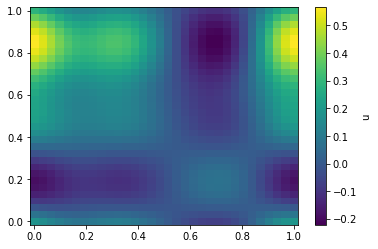

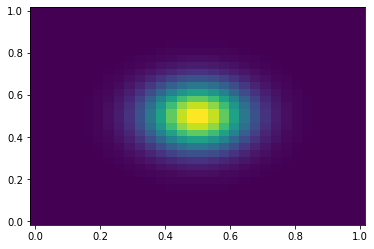

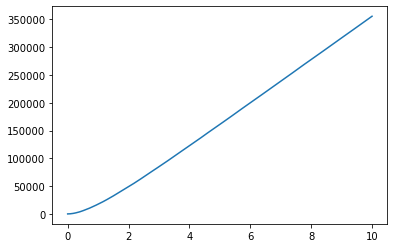

In [66]:
plt.figure()
plt.pcolormesh(x,y,u_init,shading='auto')
plt.colorbar(label='u')

plt.figure()
plt.pcolormesh(x,y,u_t1,shading='auto')
plt.colorbar(label='u')

plt.figure()
plt.pcolormesh(x,y,u_t10,shading='auto')
plt.colorbar(label='u')

plt.figure()
u_final = unflatten(u_exact[-1,:])
plt.pcolormesh(x,y,u_final,shading='auto')

plt.figure()
L2_CTU_cumul = np.cumsum(L2_CTU)
plt.plot(t, L2_CTU_cumul)

plt.show()